In [ ]:
#Visualization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("wine.csv")
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
df.shape

(178, 14)

In [4]:
df.size

2492

In [5]:
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["Type"].value_counts()

Type
2    71
1    59
3    48
Name: count, dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [9]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


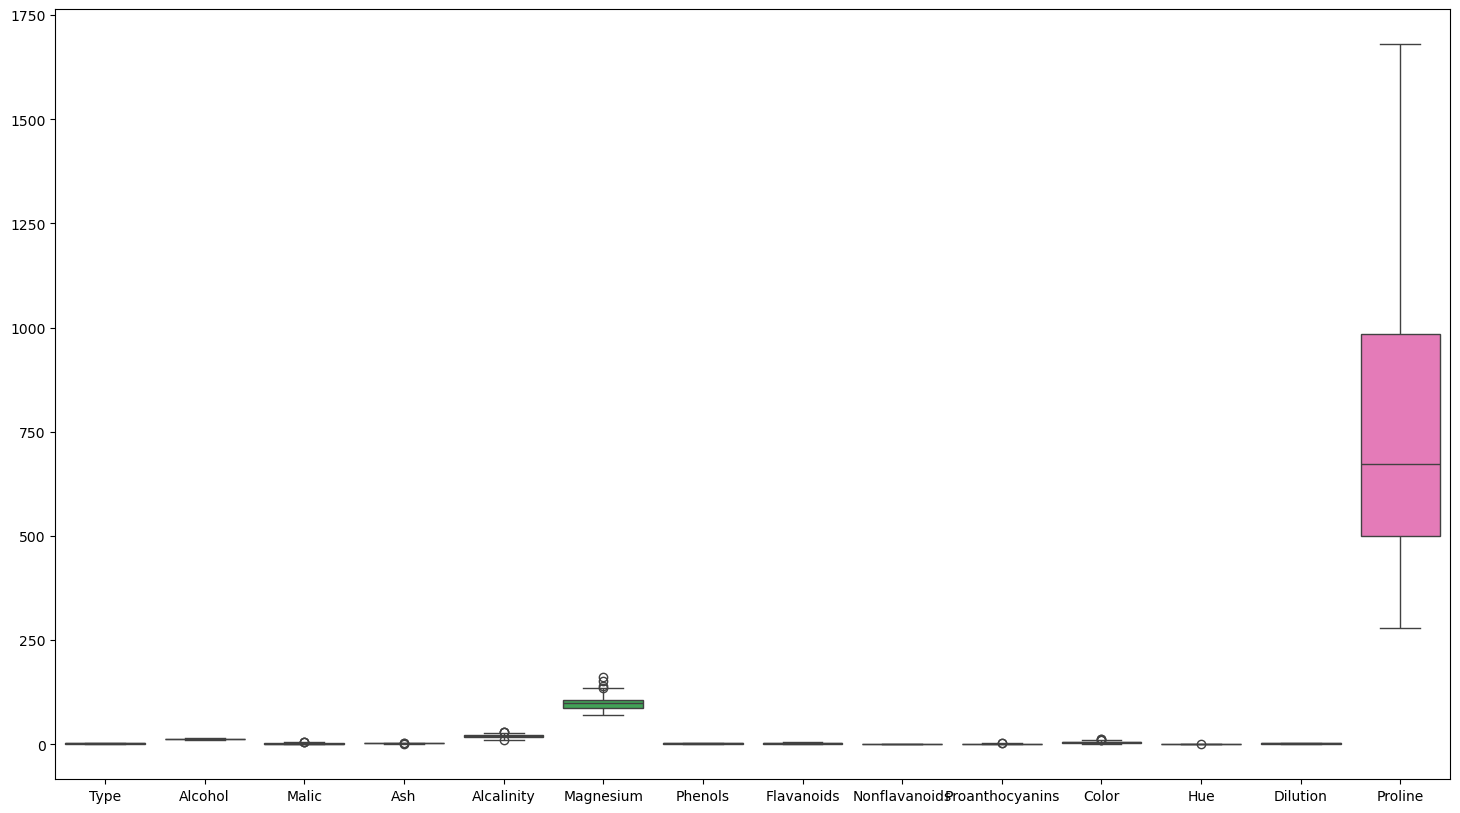

In [10]:
plt.figure(figsize=(18,10))
sns.boxplot(df)
plt.show()

In [11]:
for i in df.select_dtypes(include=["int","float"]).columns:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    IQR=q3-q1
    lower_bond=q1-1.5*IQR
    upper_bond=q3+1.5*IQR
    df[i]=df[i].clip(lower_bond,upper_bond)

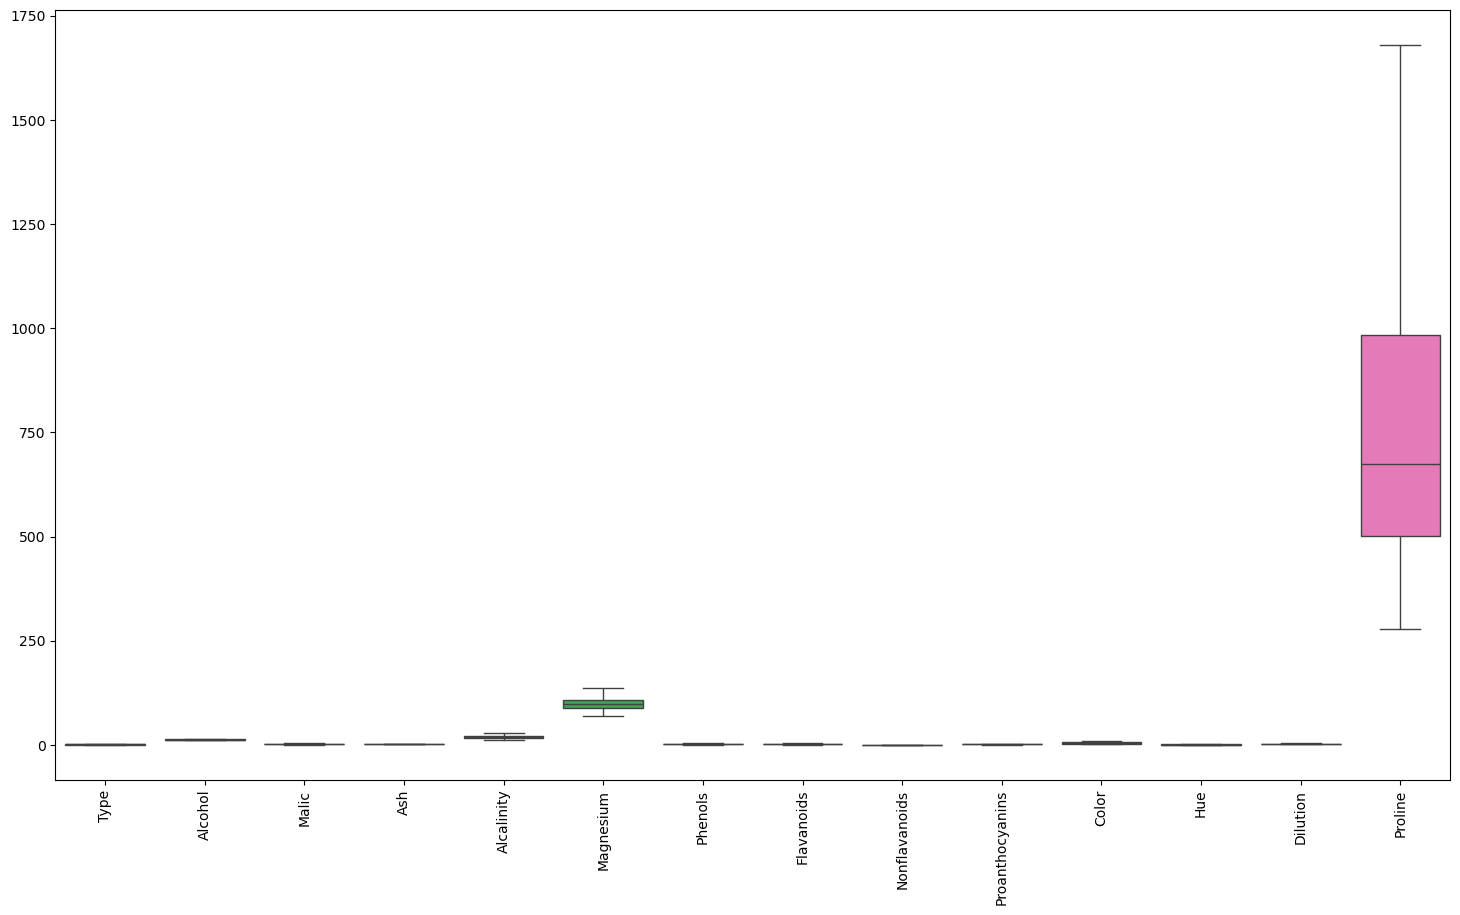

In [12]:
plt.figure(figsize=(18,10))
sns.boxplot(df)
plt.xticks(rotation=90)
plt.show()

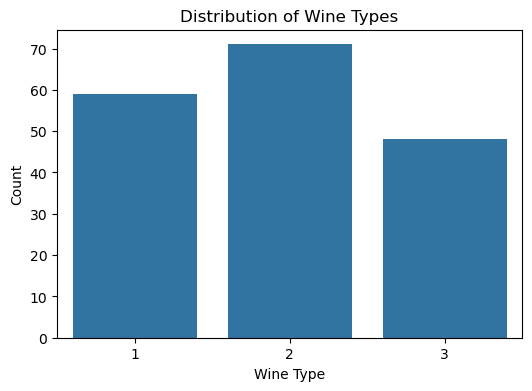

In [13]:
#visualization
plt.figure(figsize=(6,4))
sns.countplot(x='Type',data=df)
plt.title("Distribution of Wine Types")
plt.xlabel("Wine Type")
plt.ylabel("Count")

plt.show()

In [14]:
# This helps us understand whether the three wine classes are reasonably balanced.

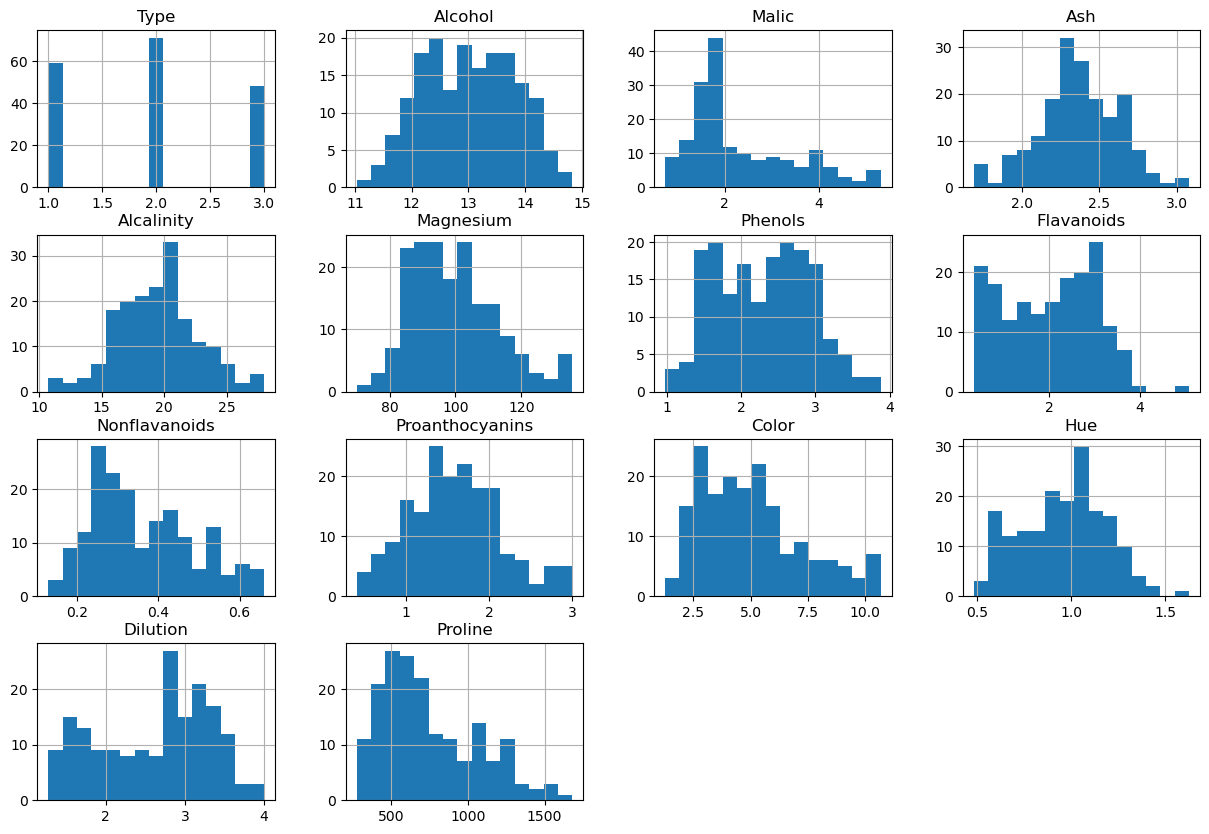

In [15]:
#Histogram
df.hist(figsize=(15,10),bins=15)
plt.tight_layout
plt.show()

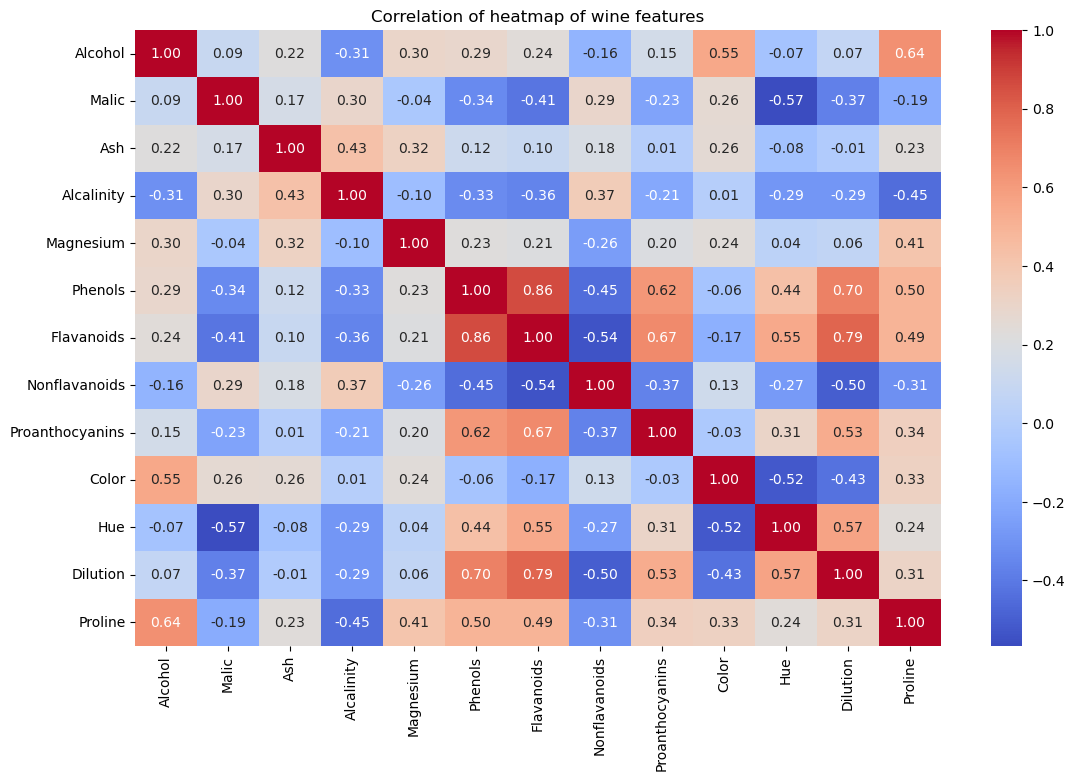

In [16]:
#orrelation Heatmap
plt.figure(figsize=(13,8))

sns.heatmap(df.drop(columns=["Type"]).corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation of heatmap of wine features")
plt.show()

In [ ]:
# you may observe strong relationships among:

# Phenols - Flavanoids, Flavanoids - Dilution, Flavanoids - Proanthocyanins.

# Strong correlations suggest that some variables contain similar/redundant information.

In [17]:
#Separeting the features and Target
x=df.drop(columns=["Type"])
y=df["Type"]

In [18]:
print("Features shape:",x.shape)
print("Target shape:",y.shape)

Features shape: (178, 13)
Target shape: (178,)


In [19]:
#Standardize the features

from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_scaled=sc.fit_transform(x)
print(x_scaled.shape)

(178, 13)


In [ ]:
# some features have high values if we directly apply PCA features with larger
# numerical values can have too much influence

In [ ]:
# So we have applied standardScaler so that it convers every feature approximatly to mean=0 and std=1

In [ ]:
#Now we can apply PCA

In [20]:
from sklearn.decomposition import PCA
pca=PCA()
x_pca=pca.fit_transform(x_scaled)
print("Original shape:", x_scaled.shape)
print("PCA shape:", x_pca.shape)

Original shape: (178, 13)
PCA shape: (178, 13)


In [ ]:
# We still have 13 columns!

# That's because we haven't decided how many components to keep yet.

In [21]:
#Explained Variance Ratio
explained_variance = pca.explained_variance_ratio_
print(explained_variance)

[0.36475803 0.19609775 0.10911182 0.07062378 0.06296983 0.04815067
 0.04031504 0.02744533 0.02232516 0.01931106 0.01755433 0.01326634
 0.00807088]


In [22]:
#Cumulative Explained Variance
cumulative_variance = np.cumsum(explained_variance)
print(cumulative_variance)

[0.36475803 0.56085577 0.66996759 0.74059137 0.8035612  0.85171187
 0.89202691 0.91947224 0.9417974  0.96110846 0.97866279 0.99192912
 1.        ]


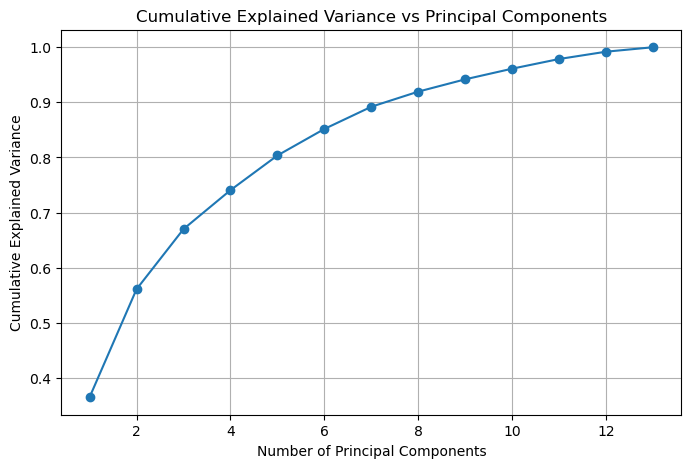

In [23]:
#Plot Cumulative Explained Variance
plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance vs Principal Components")
plt.grid()
plt.show()

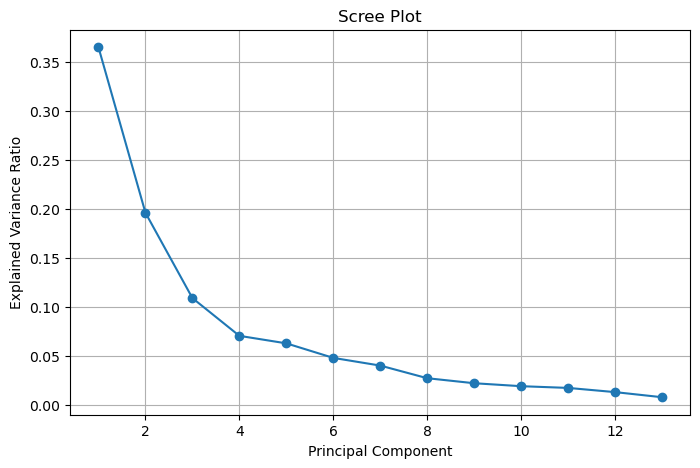

In [24]:
#Screen Plot
#We can also visualize the individual explained variance.
plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker='o'
)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")

plt.grid()
plt.show()

In [ ]:
# It helps identify where the additional components start contributing relatively little information.

In [25]:
#Choose NUmber of Components
#Instead of guessing, let's find how many components are needed to retain 95% of the variance.

n_components = np.argmax(cumulative_variance >= 0.95) + 1
print("Number of components required for 95% variance:", n_components)

Number of components required for 95% variance: 10


In [26]:
#Applying PCA with selected components
pca_final = PCA(n_components=n_components)
x_pca_final = pca_final.fit_transform(x_scaled)
print("Original data shape:", x.shape)
print("Reduced data shape:", x_pca_final.shape)

Original data shape: (178, 13)
Reduced data shape: (178, 10)


In [ ]:
# We've reduced:

# 13 dimensions - 10 dimensions

# while retaining 95% of the information.

In [27]:
#Create PCA DataFrame
pca_columns = [f'pc{i+1}' for i in range(n_components)]

df_pca=pd.DataFrame(x_pca_final,columns=pca_columns)
df_pca.head()

,pc1,pc2,pc3,pc4,pc5,pc6,pc7,pc8,pc9,pc10
0,3.358147,1.520222,-0.126375,-0.224356,0.710891,0.176645,0.701154,0.019187,-0.689257,-1.031209
1,2.229215,-0.333261,-2.042838,-0.365783,-0.107448,0.984902,0.048001,0.991649,0.379664,-0.208787
2,2.540057,1.036953,1.018845,0.766907,-0.363113,-0.537666,0.412691,-0.464401,1.164755,-0.136538
3,3.781124,2.782566,-0.149224,0.593304,-0.273054,-0.132210,-0.394978,0.694895,-0.001904,-0.241293
4,1.016872,0.955225,2.113169,-0.431732,0.357108,0.386733,0.487160,0.377559,-0.283486,0.036566


In [ ]:
# PCA does not simply select existing columns. It creates new dimensions that capture the maximum possible variance in the data.

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [29]:
inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known

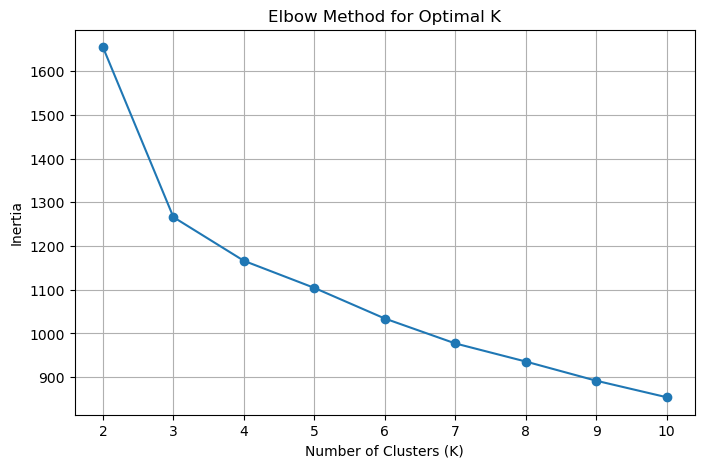

In [30]:
#Ploting the Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.grid()
plt.show()

In [ ]:
# We look for the point where the decrease in inertia starts becoming much smaller. This is called the elbow point.

In [31]:
#Calculating Silhouette Score for Different K 
silhouette_scores = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(x_scaled)
    
    score = silhouette_score(x_scaled, labels)
    silhouette_scores.append(score)
    
    print(f"K = {k}, Silhouette Score = {score:.4f}")

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K = 2, Silhouette Score = 0.2683
K = 3, Silhouette Score = 0.2855
K = 4, Silhouette Score = 0.2415


C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K = 5, Silhouette Score = 0.2319
K = 6, Silhouette Score = 0.1860
K = 7, Silhouette Score = 0.1565


C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K = 8, Silhouette Score = 0.1530
K = 9, Silhouette Score = 0.1388


C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K = 10, Silhouette Score = 0.1412


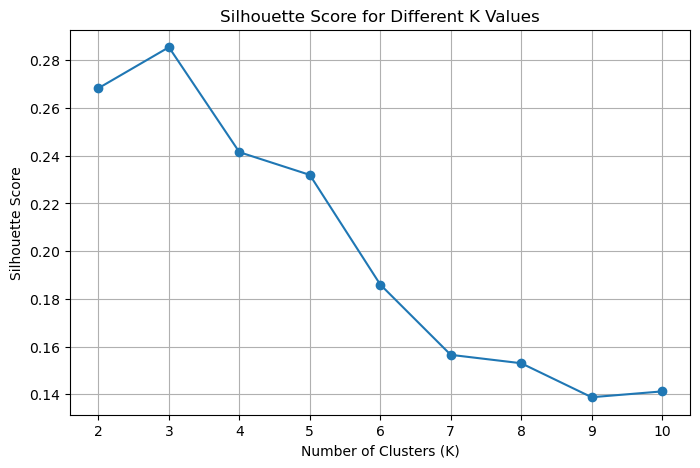

In [32]:
#Ploting the silhouette Scores
plt.figure(figsize=(8,5))
plt.plot(
    K_range,
    silhouette_scores,
    marker='o'
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.grid()
plt.show()

In [ ]:
# This helps us determine which K gives better-separated clusters.

In [ ]:
# Building Final K-Means Model

In [33]:
#Building Final K-Means Model
kmeans_original = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
clusters_original = kmeans_original.fit_predict(x_scaled)

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [34]:
#Adding cluster labels to Dataset
df_original_clustered = df.copy()
df_original_clustered['Cluster'] = clusters_original
df_original_clustered.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline,Cluster
0,1,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2
1,1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2
2,1,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2
3,1,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2
4,1,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2


In [35]:
#Evaluate the Clustering
silhouette_original = silhouette_score(
    x_scaled,
    clusters_original
)
print("Silhouette Score:", round(silhouette_original, 4))

Silhouette Score: 0.2855


In [36]:
db_original = davies_bouldin_score(
    x_scaled,
    clusters_original
)
print("Davies-Bouldin Index:", round(db_original, 4))

Davies-Bouldin Index: 1.3816


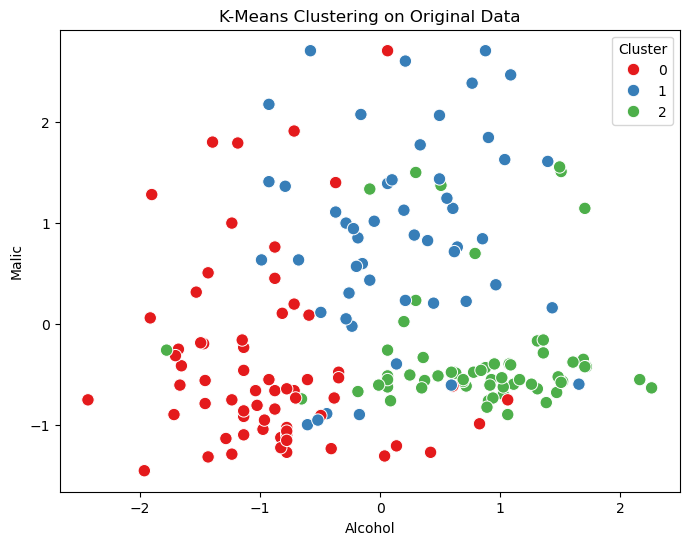

In [37]:
#Visualizing the clusters
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=x_scaled[:, 0],
    y=x_scaled[:, 1],
    hue=clusters_original,
    palette='Set1',
    s=80
)
plt.xlabel("Alcohol")
plt.ylabel("Malic")
plt.title("K-Means Clustering on Original Data")

plt.legend(title="Cluster")

plt.show()

In [ ]:
# Analysis:

In [ ]:
# The K-Means clustering results were visualized using Alcohol and Malic as the two dimensions. Three distinct clusters were identified and represented using different colors. Although some overlap exists between the clusters, the visualization shows that K-Means is able to identify groups of similar observations based on the feature values.

In [38]:
#Checking PCA Data
print("Original data shape:", x_scaled.shape)
print("PCA data shape:", x_pca_final.shape)

Original data shape: (178, 13)
PCA data shape: (178, 10)


In [39]:
inertia_pca = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(x_pca_final)
    inertia_pca.append(kmeans.inertia_)

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known

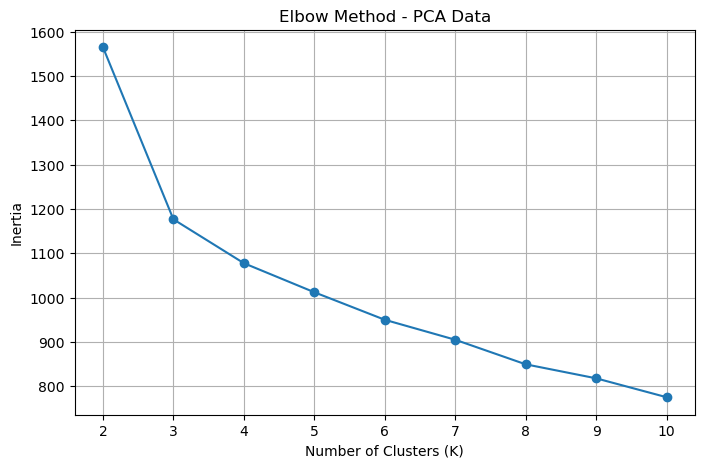

In [40]:
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia_pca, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method - PCA Data")
plt.grid()
plt.show()

In [41]:
#calculating the Silhouette Score
silhouette_pca = []

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(x_pca_final)
    score = silhouette_score(x_pca_final, labels)
    silhouette_pca.append(score)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K = 2, Silhouette Score = 0.2793
K = 3, Silhouette Score = 0.2992
K = 4, Silhouette Score = 0.2533
K = 5, Silhouette Score = 0.2424


C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K = 6, Silhouette Score = 0.1930
K = 7, Silhouette Score = 0.1484
K = 8, Silhouette Score = 0.1583


C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K = 9, Silhouette Score = 0.1466
K = 10, Silhouette Score = 0.1602


C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


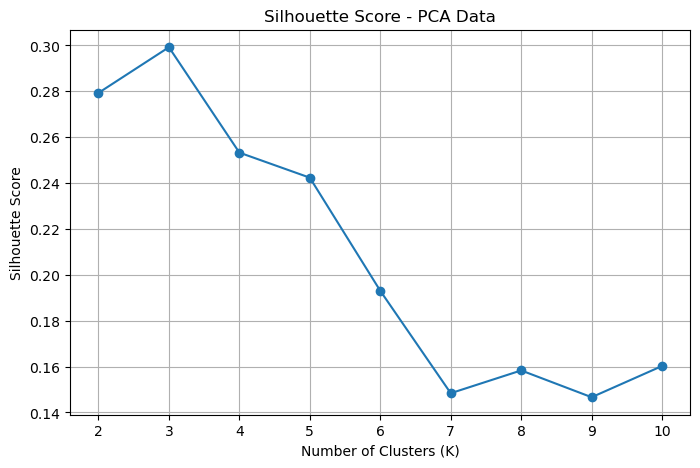

In [42]:
plt.figure(figsize=(8,5))

plt.plot(
    K_range,
    silhouette_pca,
    marker='o'
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score - PCA Data")

plt.grid()
plt.show()

In [43]:
#Applying K-Means where K=3
kmeans_pca = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
clusters_pca = kmeans_pca.fit_predict(x_pca_final)

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [44]:
silhouette_pca_final = silhouette_score(
    x_pca_final,
    clusters_pca
)

print(
    "PCA Silhouette Score:",
    round(silhouette_pca_final, 4)
)

PCA Silhouette Score: 0.2992


In [45]:
db_pca = davies_bouldin_score(
    x_pca_final,
    clusters_pca
)

print(
    "PCA Davies-Bouldin Index:",
    round(db_pca, 4)
)

PCA Davies-Bouldin Index: 1.3289


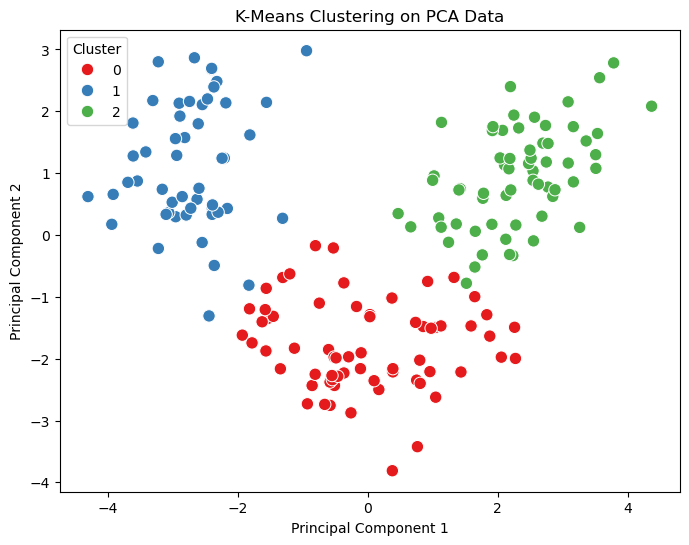

In [46]:
#Visualize PCA Clusters
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=x_pca_final[:, 0],
    y=x_pca_final[:, 1],
    hue=clusters_pca,
    palette='Set1',
    s=80
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering on PCA Data")
plt.legend(title="Cluster")
plt.show()

In [47]:
#Craete PCA Cluster DataFrame
df_pca_clustered = df_pca.copy()
df_pca_clustered['Cluster'] = clusters_pca
df_pca_clustered.head()

,pc1,pc2,pc3,pc4,pc5,pc6,pc7,pc8,pc9,pc10,Cluster
0,3.358147,1.520222,-0.126375,-0.224356,0.710891,0.176645,0.701154,0.019187,-0.689257,-1.031209,2
1,2.229215,-0.333261,-2.042838,-0.365783,-0.107448,0.984902,0.048001,0.991649,0.379664,-0.208787,2
2,2.540057,1.036953,1.018845,0.766907,-0.363113,-0.537666,0.412691,-0.464401,1.164755,-0.136538,2
3,3.781124,2.782566,-0.149224,0.593304,-0.273054,-0.132210,-0.394978,0.694895,-0.001904,-0.241293,2
4,1.016872,0.955225,2.113169,-0.431732,0.357108,0.386733,0.487160,0.377559,-0.283486,0.036566,2


In [48]:
#Comparison and Analysis
comparison = pd.DataFrame({
    'Method': [
        'Original Data',
        'PCA Data'
    ],
    
    'Silhouette Score': [
        silhouette_original,
        silhouette_pca_final
    ],
    
    'Davies-Bouldin Index': [
        db_original,
        db_pca
    ]
})

comparison

,Method,Silhouette Score,Davies-Bouldin Index
0,Original Data,0.285463,1.381606
1,PCA Data,0.299241,1.328918


In [ ]:
#Here PCA Silhouette > Original Silhouette  then PCA produced better-separated clusters according to the Silhouette metric.
#And PCA DB Index < Original DB Index then PCA also produced better clustering according to Davies-Bouldin.

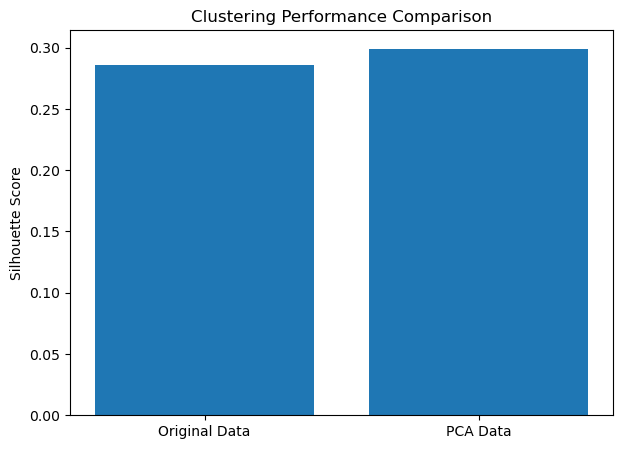

In [49]:
#Visual Comparison
plt.figure(figsize=(7,5))
methods = ['Original Data', 'PCA Data']
scores = [silhouette_original, silhouette_pca_final]
plt.bar(methods, scores)
plt.ylabel("Silhouette Score")
plt.title("Clustering Performance Comparison")
plt.show()

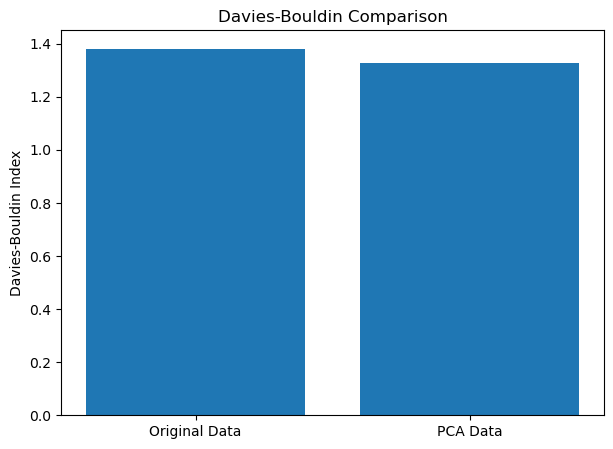

In [50]:
#Davies-Bouldin
plt.figure(figsize=(7,5))

db_scores = [db_original, db_pca]
plt.bar(methods, db_scores)
plt.ylabel("Davies-Bouldin Index")
plt.title("Davies-Bouldin Comparison")
plt.show()

In [ ]:
# Analysis:

In [ ]:
# K-Means clustering was performed on both the standardized original dataset and the PCA-transformed dataset. The original data produced a Silhouette Score of 0.285463 and a Davies-Bouldin Index of 1.381606. After applying PCA, the Silhouette Score improved to 0.299241, while the Davies-Bouldin Index decreased to 1.328918. Since a higher Silhouette Score and lower Davies-Bouldin Index indicate better clustering, the PCA-based approach performed slightly better. The results suggest that PCA helped reduce redundant information and improved cluster separation to a modest extent. However, PCA reduces interpretability because the new principal components are combinations of the original features.

In [ ]:
# 1. Summary of Key Findings:
    
# Conclusion: In this assignment, Exploratory Data Analysis, Principal Component Analysis (PCA), and K-Means clustering were performed on the Wine dataset. The dataset contained 178 observations, 13 numerical features, and one class variable. EDA showed that the features had different scales and several features were strongly correlated.

# The numerical features were standardized before applying PCA. PCA was then used to reduce the dimensionality of the dataset while retaining most of the important information. K-Means clustering was performed on both the standardized original data and PCA-transformed data using three clusters.

# The clustering performance was evaluated using Silhouette Score and Davies-Bouldin Index. The original data achieved a Silhouette Score of 0.285463 and a Davies-Bouldin Index of 1.381606, while the PCA data achieved a Silhouette Score of 0.299241 and a Davies-Bouldin Index of 1.328918. Therefore, the PCA-based clustering performed slightly better according to both metrics.

In [ ]:
# 2. Practical Implications of PCA and Clustering:

# PCA is useful when:

# If the Dataset has many features. The Features are highly correlated. IF We want to reduce dimensionality and computational complexity. IF We want to visualize high-dimensional data. IF We want to remove some redundant information.

# Clustering is useful when:

# When We don't have labeled target data. If We want to discover natural groups. We want to segment customers. We want to group products. We want to identify similar observations. We want to discover hidden patterns. For all these we use Clustering

In [ ]:
# Conclusion:

# The analysis demonstrated that PCA can be effectively combined with K-Means clustering to reduce dimensionality and identify meaningful groups within a dataset. In this Wine dataset, PCA resulted in a modest improvement in clustering performance, with the Silhouette Score increasing from 0.285463 to 0.299241 and the Davies-Bouldin Index decreasing from 1.381606 to 1.328918. However, PCA comes with a trade-off because the transformed principal components are less interpretable than the original features. Therefore, PCA should be considered when dealing with high-dimensional or highly correlated datasets, while clustering can be applied when the primary objective is to discover natural groups or patterns in unlabeled data.